In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
v = 0.01

Nx = 256
xs = np.linspace(-1, 1, Nx)
dx = 2/ Nx
u0 = -np.sin(np.pi * xs)

In [4]:
def burgers_rhs(t, u):
    dudt = np.zeros_like(u)

    # First derivative (central)
    ux = (u[2:] - u[:-2]) / (2 * dx)

    # Second derivative (central)
    uxx = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)

    # Burgers equation
    dudt[1:-1] = -u[1:-1] * ux + v * uxx

    # Dirichlet BCs (u = 0 at boundaries)
    dudt[0] = 0.0
    dudt[-1] = 0.0

    return dudt

In [5]:
ts, us = ODE_system_solver(burgers_rhs, u0, 0, 1, 1e-4)

In [6]:
N_plot = 5000

idxs_t = np.random.randint(low=0, high=us.shape[0], size=N_plot)
idxs_x = np.random.randint(low=0, high=us.shape[1], size=N_plot)

X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
u_plot = us[idxs_t, idxs_x]

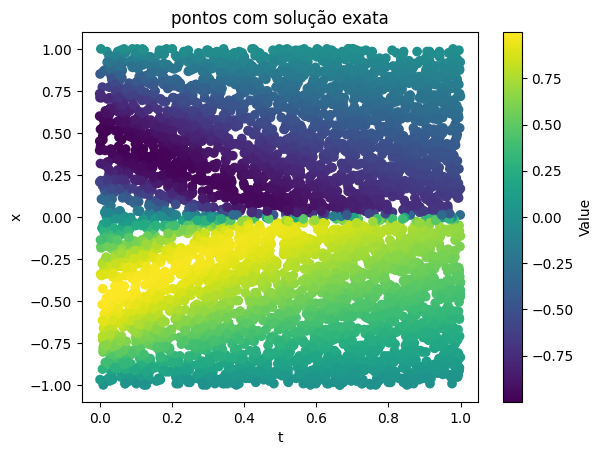

In [7]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.show()

In [8]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 0.5, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]

    dy_dxx = torch.autograd.grad(dy_dx, X_batch, grad_outputs=torch.ones_like(dy_dx), create_graph=True)[0][:, 1:]

    if make_reduction:
        L_f = torch.mean((dy_dt + y_fake * dy_dx - v * dy_dxx) ** 2)
        L_b1 = torch.mean((y_inicial + torch.sin(np.pi * X_inicial[:, 1:])) ** 2)
        L_b2 = torch.mean((y_contorno - 0) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (dy_dt + y_fake * dy_dx - v * dy_dxx) ** 2
        L_b1 = (y_inicial + torch.sin(np.pi * X_inicial[:, 1:])) ** 2
        L_b2 = (y_contorno - 0) ** 2

        return L_f, L_b1, L_b2



In [9]:
def sample_points(N_colocacao, N_contorno, N_inicial):
    X_colocacao = torch.cat([
        torch.rand(N_colocacao, 1),
        2.0 * torch.rand(N_colocacao, 1) - 1.0
    ], dim = 1)

    X_contorno = torch.cat([
        torch.cat([torch.rand(N_contorno // 2, 1), -torch.ones(N_contorno // 2, 1)], dim = 1),
        torch.cat([torch.rand(N_contorno - N_contorno // 2, 1), torch.ones(N_contorno - N_contorno // 2, 1)], dim = 1)
    ], dim = 0)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        2.0 * torch.rand(N_inicial, 1) - 1.0
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

In [10]:
def resample_ozanski(X_colocacao, model, perc=0.2):
    N_colocacao = X_colocacao.shape[0]
    N_novos = int(N_colocacao * perc)

    X_grad = X_colocacao.detach().clone().requires_grad_(True)
    y_fake = model(X_grad)
    L_f, *_ = pinn_loss(X_grad, y_fake, torch.empty(0, 2), torch.empty(0, 1), torch.empty(0, 2), torch.empty(0, 1), 0.0, False)
    
    idxs = np.argpartition(-L_f.detach().numpy(), N_novos, axis=0).flatten()
    idxs = idxs[:N_colocacao - N_novos]

    X_novos, *_ = sample_points(N_novos, 0, 0)

    return torch.cat((X_colocacao[idxs], X_novos), axis=0)

In [11]:
N_colocacao = 5000
N_contorno = 750
N_inicial = 750

X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

In [12]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, z):
        return self.net(z)

In [13]:
n_iter = 10000

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 48)

lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)


N_change_points = 200

In [14]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    # X_batch_colocacao, X_batch_contorno, X_batch_inicial = sample_points(batch_colocacao, batch_contorno, batch_inicial)
    
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
    
    y_fake = PINN_model(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial)

    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()

    if (it + 1) % N_change_points == 0:
        X_colocacao = resample_ozanski(X_colocacao, PINN_model)
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

Iter 1000: L_PINN=0.0419026837
Iter 2000: L_PINN=0.0221530758
Iter 3000: L_PINN=0.0076757250
Iter 4000: L_PINN=0.0053118141
Iter 5000: L_PINN=0.0022911415
Iter 6000: L_PINN=0.0032331701
Iter 7000: L_PINN=0.0016890534
Iter 8000: L_PINN=0.0012397803
Iter 9000: L_PINN=0.0017458713
Iter 10000: L_PINN=0.0020085208


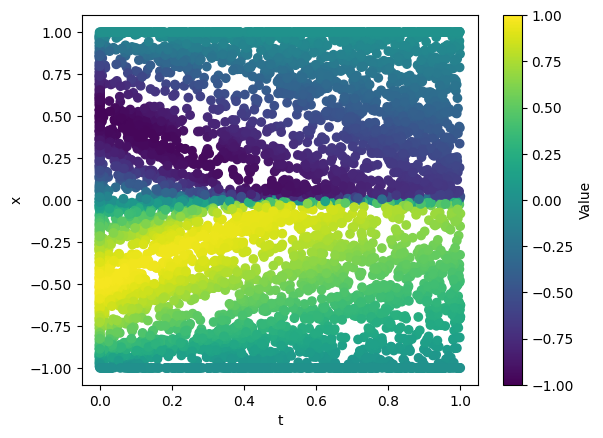

In [15]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
# x_plot = X_colocacao

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis", vmin=-1, vmax=1)
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

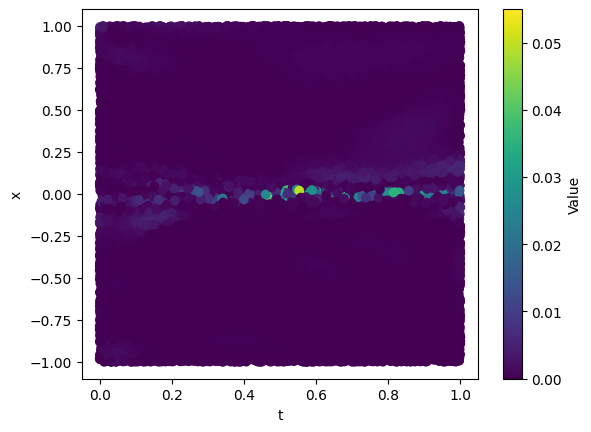

In [16]:
x_plot, *_ = sample_points(50000, 0, 0)
x_grad = x_plot.detach().clone().requires_grad_(True)
y_fake = PINN_model(x_grad)
L_f, *_ = pinn_loss(x_grad, y_fake, torch.empty(0, 2), torch.empty(0, 1), torch.empty(0, 2), torch.empty(0, 1), 0.0, False)

x_plot = x_plot.detach().numpy()
L_f = L_f.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=L_f, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()